# Fase 4 — Interacciones 2-way entre VI de tarea

**Objetivo:** Determinar si los **efectos base** documentados en la Fase 3 se mantienen de forma **aditiva** o dependen de la **combinación** con otra variable independiente de tarea (interacción). Este análisis guiará la especificación de términos de interacción en los GLMM de fases posteriores.

**Dataset:** `Matriz_V3.xlsx` (3 179 filas × 18 columnas).

| VD normalizada | Etiqueta corta |
|---|---|
| `Total Touches / min` | Toques / min |
| `Golpeos +15 m/s / min` | Golpeos / min |
| `Distance Covered (m) / min` | Distancia / min |
| `High Intensity Distance (20 km/h) / min` | HID / min |

| VI de tarea | Niveles |
|---|---|
| `Formato_del_Juego` | SSG / LSG |
| `Polaridad` | polarizado / no polarizado |
| `Equilibrio` | equilibrio / desequilibrio |

### Pares de VI analizados (C(3,2) = 3)

1. Formato_del_Juego × Polaridad
2. Formato_del_Juego × Equilibrio
3. Polaridad × Equilibrio

**Combinaciones totales:** 3 pares × 4 VD = **12 análisis de interacción**.

> **Nota:** No se incluye `GrupoEdad` como factor en este notebook. Las interacciones con GrupoEdad se abordarán en los modelos GLMM.

In [1]:
# ── Librerías ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings

# statsmodels para ANOVA factorial y regresión logística
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

from IPython.display import display, Markdown

# ── Configuración global ──────────────────────────────────
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 200,
    "figure.facecolor": "white",
    "axes.facecolor": "#FAFAFA",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlepad": 12,
    "axes.labelpad": 8,
    "grid.alpha": 0.30,
    "grid.linewidth": 0.5,
    "grid.color": "#CCCCCC",
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
})
%matplotlib inline

# ── Carga del dataset ─────────────────────────────────────
df = pd.read_excel("../Datos/Matriz_V3.xlsx")
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

# ── Variables dependientes normalizadas ───────────────────
vd_cols = [
    "Total Touches / min",
    "Golpeos +15 m/s / min",
    "Distance Covered (m) / min",
    "High Intensity Distance (20 km/h) / min",
]

vd_labels = [
    "Toques / min",
    "Golpeos / min",
    "Distancia / min",
    "HID / min",
]

vd_to_label = dict(zip(vd_cols, vd_labels))
label_to_vd = dict(zip(vd_labels, vd_cols))

# ── Variables independientes de tarea ─────────────────────
vi_cols = ["Formato_del_Juego", "Polaridad", "Equilibrio"]

# Niveles ordenados de cada VI
vi_niveles = {vi: sorted(df[vi].dropna().unique().tolist()) for vi in vi_cols}

# ── Generación de los 3 pares de VI ──────────────────────
pares_vi = list(combinations(vi_cols, 2))
print(f"\n✔ {len(pares_vi)} pares de VI generados:")
for i, (v1, v2) in enumerate(pares_vi, 1):
    print(f"   {i}. {v1} × {v2}")

# ── VD con inflación de ceros ─────────────────────────────
vd_zeros = ["Golpeos +15 m/s / min", "High Intensity Distance (20 km/h) / min"]
vd_zeros_labels = ["Golpeos / min", "HID / min"]

# ── Paletas de colores ────────────────────────────────────
colores_vd = sns.color_palette("Set2", n_colors=len(vd_cols))
vd_to_color = dict(zip(vd_cols, colores_vd))
PAL_NIVEL = ["#5A9BD5", "#F28E2B"]   # Azul acero · Naranja cálido
PAL_INTER = ["#2C7BB6", "#D7191C"]   # Azul oscuro · Rojo — para líneas de interacción

# ── Verificación ──────────────────────────────────────────
for col in vd_cols + vi_cols:
    assert col in df.columns, f"Columna '{col}' no encontrada."
print(f"\n✔ {len(vd_cols)} VD y {len(vi_cols)} VI verificadas.")
print(f"✔ {len(pares_vi)} pares × {len(vd_cols)} VD = {len(pares_vi) * len(vd_cols)} combinaciones de interacción.")

Dimensiones: 3179 filas × 18 columnas

✔ 3 pares de VI generados:
   1. Formato_del_Juego × Polaridad
   2. Formato_del_Juego × Equilibrio
   3. Polaridad × Equilibrio

✔ 4 VD y 3 VI verificadas.
✔ 3 pares × 4 VD = 12 combinaciones de interacción.


---
## Sección 1 — Tablas de medias cruzadas 2×2

Para cada par de VI × cada VD se calcula la **media**, **SD** y **N** en las 4 celdas del cruce factorial. Para **Golpeos/min** y **HID/min**, se añade además el **% de ceros** y la **media condicional (> 0)** en cada celda, extendiendo el enfoque interruptor/modulador de la Fase 3 al contexto cruzado.

In [2]:
# ── Sección 1: Tablas de medias cruzadas 2×2 ─────────────

for vi1, vi2 in pares_vi:
    display(Markdown(f"### Par: **{vi1} × {vi2}**"))
    
    filas = []
    for vd, label in zip(vd_cols, vd_labels):
        for niv1 in vi_niveles[vi1]:
            for niv2 in vi_niveles[vi2]:
                sub = df[(df[vi1] == niv1) & (df[vi2] == niv2)][vd].dropna()
                fila = {
                    "VD": label,
                    vi1: niv1,
                    vi2: niv2,
                    "N": len(sub),
                    "Media": round(sub.mean(), 4) if len(sub) > 0 else np.nan,
                    "SD": round(sub.std(ddof=1), 4) if len(sub) > 1 else np.nan,
                }
                # Añadir info de ceros para Golpeos y HID
                if vd in vd_zeros:
                    n_ceros = int((sub == 0).sum()) if len(sub) > 0 else 0
                    pct_ceros = round((sub == 0).mean() * 100, 1) if len(sub) > 0 else np.nan
                    sub_pos = sub[sub > 0]
                    media_cond = round(sub_pos.mean(), 4) if len(sub_pos) > 0 else np.nan
                    fila["% ceros"] = pct_ceros
                    fila["Media cond. (>0)"] = media_cond
                filas.append(fila)
    
    df_tabla = pd.DataFrame(filas)
    display(df_tabla.style.set_caption(f"Medias cruzadas: {vi1} × {vi2}").format(precision=4))
    print()

### Par: **Formato_del_Juego × Polaridad**

,VD,Formato_del_Juego,Polaridad,N,Media,SD,% ceros,Media cond. (>0)
0,Toques / min,LSG,No_polarizado,136,2.2224,0.9946,nan,nan
1,Toques / min,LSG,Polarizado,1501,1.6616,0.8929,nan,nan
2,Toques / min,SSG,No_polarizado,513,3.9041,1.9723,nan,nan
3,Toques / min,SSG,Polarizado,1029,2.8570,1.7445,nan,nan
4,Golpeos / min,LSG,No_polarizado,136,0.1039,0.1345,42.6000,0.1811
5,Golpeos / min,LSG,Polarizado,1501,0.1638,0.1702,18.3000,0.2006
6,Golpeos / min,SSG,No_polarizado,513,0.1016,0.1599,46.4000,0.1896
7,Golpeos / min,SSG,Polarizado,1029,0.1641,0.1744,29.3000,0.2322
8,Distancia / min,LSG,No_polarizado,136,91.4312,31.2193,nan,nan
9,Distancia / min,LSG,Polarizado,1501,92.3217,28.2459,nan,nan


### Par: **Formato_del_Juego × Equilibrio**

,VD,Formato_del_Juego,Equilibrio,N,Media,SD,% ceros,Media cond. (>0)
0,Toques / min,LSG,Desequilibrio,146,2.1583,1.0853,nan,nan
1,Toques / min,LSG,Equilibrio,1491,1.6641,0.8843,nan,nan
2,Toques / min,SSG,Desequilibrio,652,3.5027,1.9943,nan,nan
3,Toques / min,SSG,Equilibrio,890,2.9876,1.7767,nan,nan
4,Golpeos / min,LSG,Desequilibrio,146,0.1554,0.2096,35.6000,0.2413
5,Golpeos / min,LSG,Equilibrio,1491,0.1592,0.1638,18.8000,0.1962
6,Golpeos / min,SSG,Desequilibrio,652,0.1294,0.1758,39.9000,0.2153
7,Golpeos / min,SSG,Equilibrio,890,0.1534,0.1689,31.5000,0.2239
8,Distancia / min,LSG,Desequilibrio,146,87.1526,31.9840,nan,nan
9,Distancia / min,LSG,Equilibrio,1491,92.7466,28.0929,nan,nan


### Par: **Polaridad × Equilibrio**

,VD,Polaridad,Equilibrio,N,Media,SD,% ceros,Media cond. (>0)
0,Toques / min,No_polarizado,Desequilibrio,472,3.5429,1.8869,nan,nan
1,Toques / min,No_polarizado,Equilibrio,177,3.5754,2.0673,nan,nan
2,Toques / min,Polarizado,Desequilibrio,326,2.8425,1.9249,nan,nan
3,Toques / min,Polarizado,Equilibrio,2204,2.0450,1.3154,nan,nan
4,Golpeos / min,No_polarizado,Desequilibrio,472,0.1030,0.1623,45.6000,0.1892
5,Golpeos / min,No_polarizado,Equilibrio,177,0.0997,0.1334,45.8000,0.1837
6,Golpeos / min,Polarizado,Desequilibrio,326,0.1793,0.2004,29.8000,0.2552
7,Golpeos / min,Polarizado,Equilibrio,2204,0.1617,0.1672,21.8000,0.2067
8,Distancia / min,No_polarizado,Desequilibrio,472,73.5601,24.0724,nan,nan
9,Distancia / min,No_polarizado,Equilibrio,177,82.0292,26.3043,nan,nan


---
## Sección 2 — Interaction plots (line plots)

Para cada par de VI (VI₁ × VI₂) y cada VD:
- **Eje X:** niveles de VI₂.
- **Líneas:** niveles de VI₁ (con colores distintos).
- **Eje Y:** media de la VD ± SE (barras de error).

Si las líneas se **cruzan o divergen** → evidencia visual de interacción. Si son **paralelas** → efectos aditivos.

Layout: 1 figura × 4 paneles (uno por VD) para cada par de VI → **3 figuras** en total.

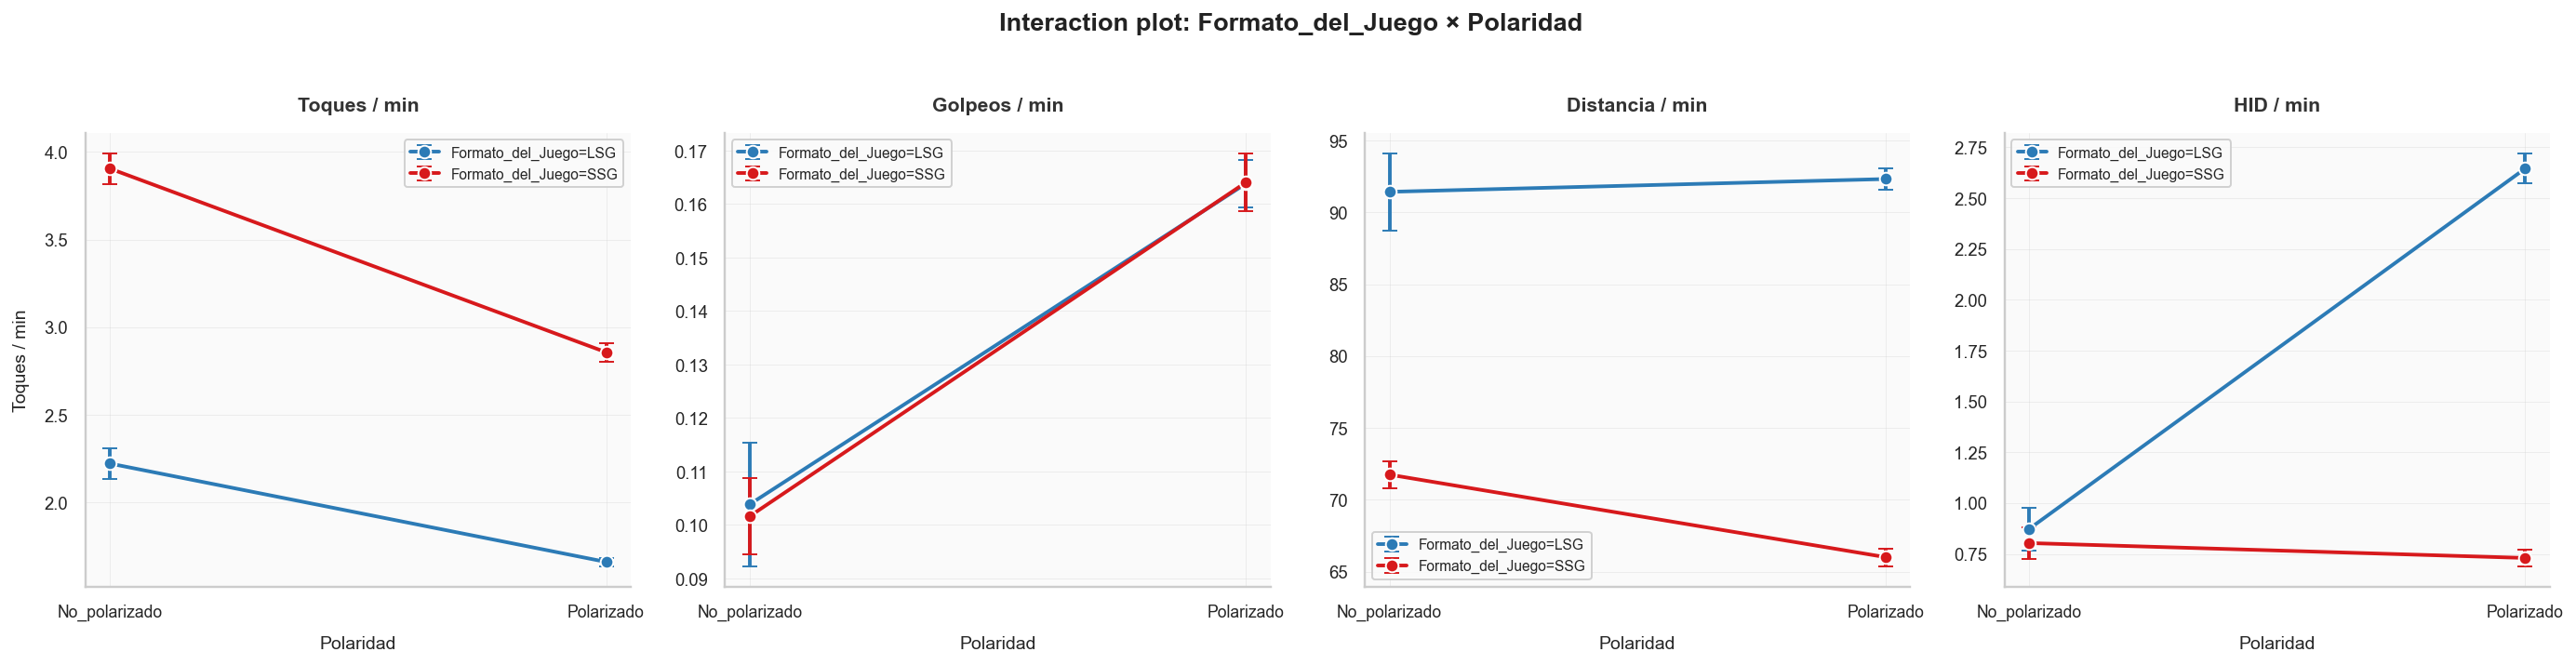

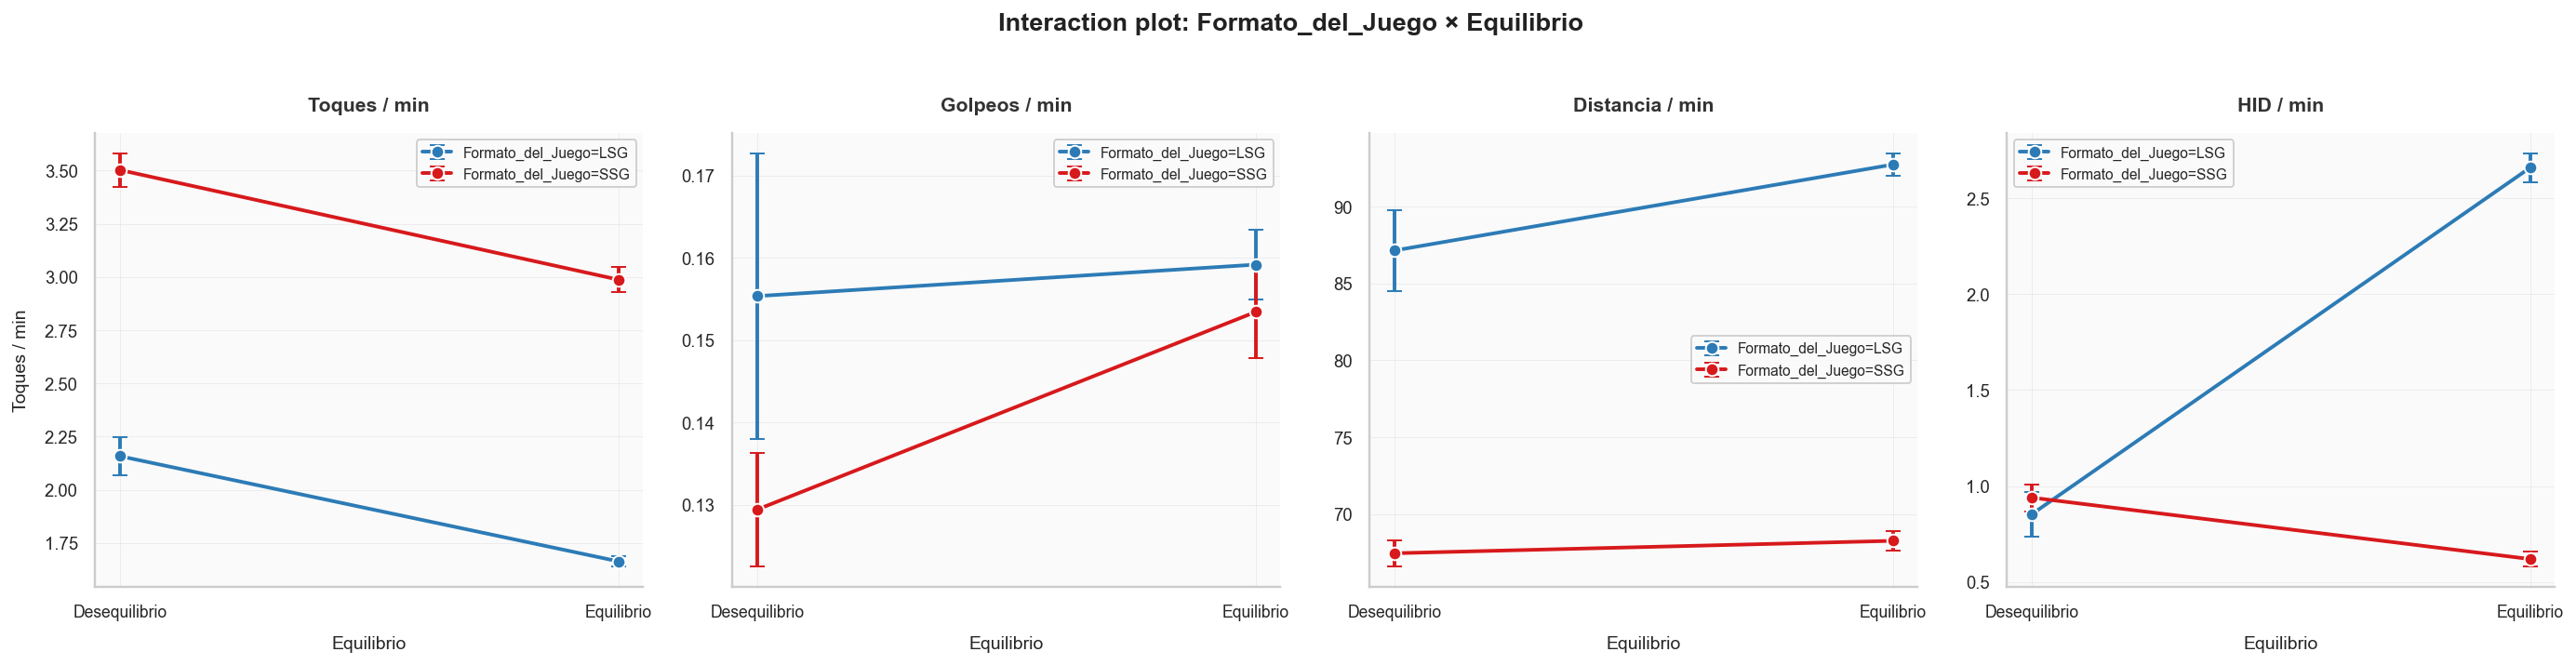

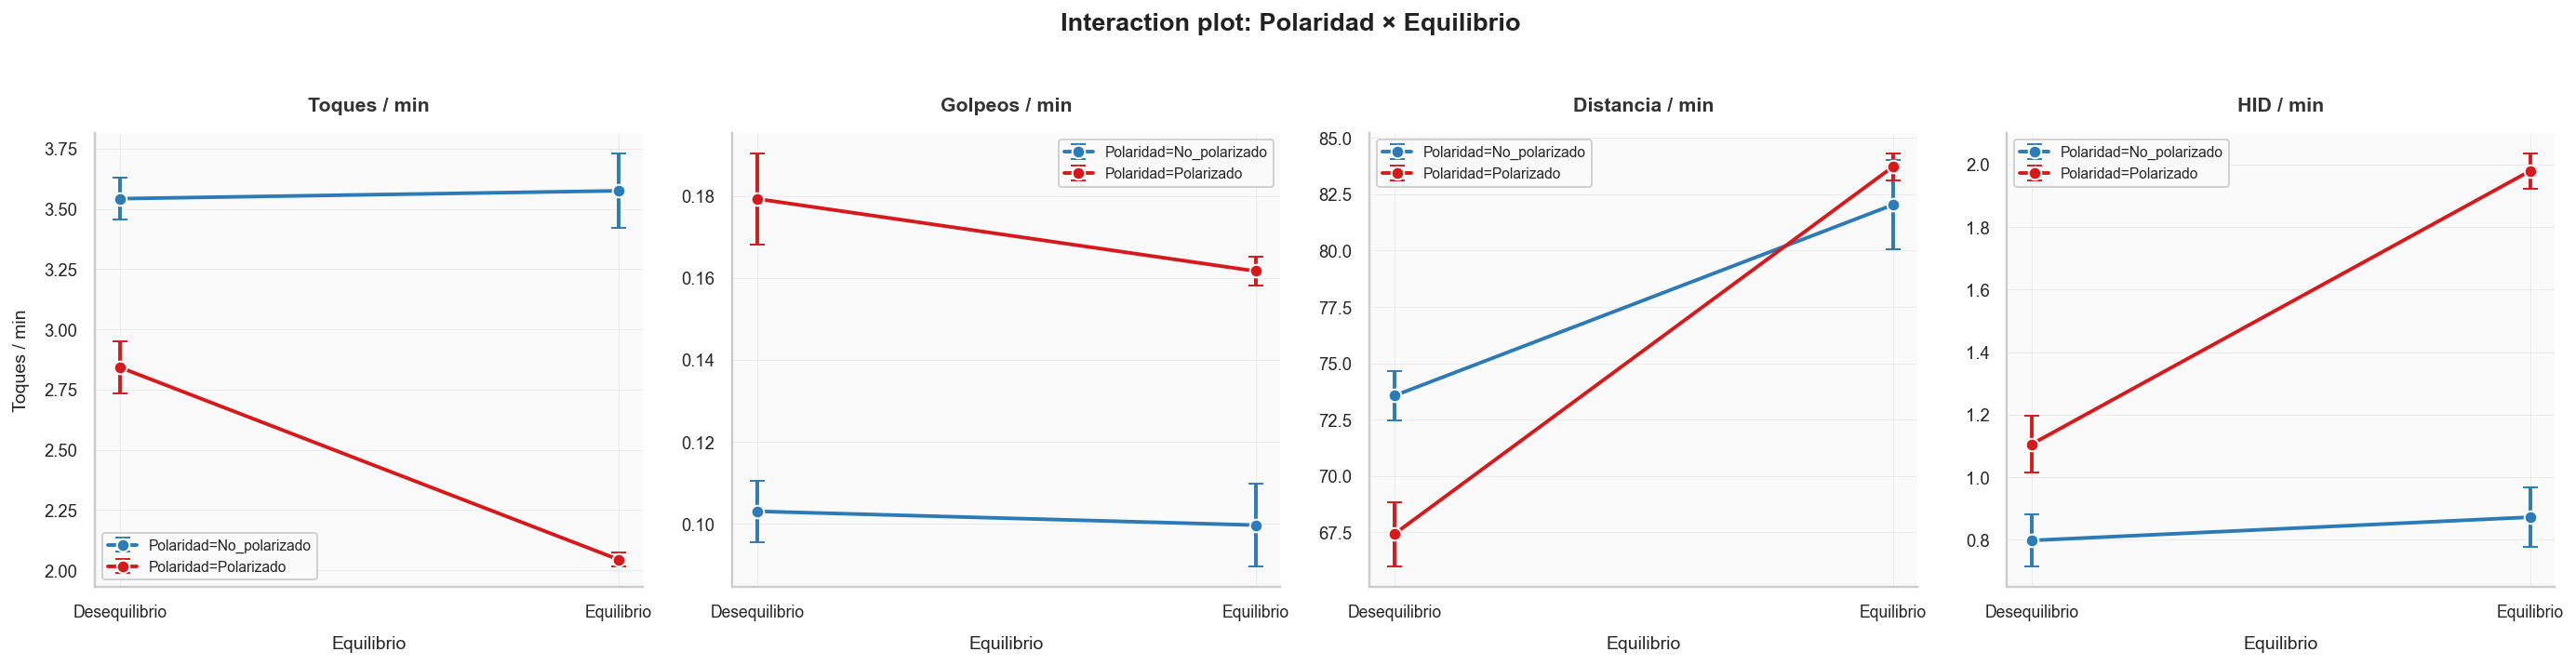

In [3]:
# ── Sección 2: Interaction plots ─────────────────────────

for vi1, vi2 in pares_vi:
    niveles_vi1 = vi_niveles[vi1]
    niveles_vi2 = vi_niveles[vi2]
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    for idx, (vd, label) in enumerate(zip(vd_cols, vd_labels)):
        ax = axes[idx]
        
        for k, niv1 in enumerate(niveles_vi1):
            medias = []
            ses = []
            for niv2 in niveles_vi2:
                sub = df[(df[vi1] == niv1) & (df[vi2] == niv2)][vd].dropna()
                medias.append(sub.mean())
                se = sub.std(ddof=1) / np.sqrt(len(sub)) if len(sub) > 1 else 0
                ses.append(se)
            
            ax.errorbar(
                range(len(niveles_vi2)), medias, yerr=ses,
                marker="o", markersize=7, capsize=4, capthick=1.2,
                linewidth=2.0, color=PAL_INTER[k], label=f"{vi1}={niv1}",
                markeredgecolor="white", markeredgewidth=1.0,
            )
        
        ax.set_xticks(range(len(niveles_vi2)))
        ax.set_xticklabels(niveles_vi2, fontsize=9)
        ax.set_xlabel(vi2, fontsize=10)
        ax.set_ylabel(label if idx == 0 else "", fontsize=10)
        ax.set_title(label, fontsize=11, fontweight="bold", color="#333")
        ax.legend(fontsize=8, loc="best", framealpha=0.9)
    
    fig.suptitle(
        f"Interaction plot: {vi1} × {vi2}",
        fontsize=14, fontweight="bold", color="#222", y=1.02,
    )
    fig.tight_layout()
    plt.show()

---
## Sección 3 — ANOVA factorial 2×2 y cuantificación de la interacción

Para cada par (VI₁ × VI₂) × cada VD:

1. **ANOVA factorial 2×2** con `statsmodels` (OLS + Type II SS) para obtener:
   - F y p del efecto principal de VI₁
   - F y p del efecto principal de VI₂
   - F y p del término de interacción VI₁ × VI₂
   - η²p (eta-cuadrado parcial) de la interacción

2. **Diferencia de diferencias (ΔΔ):**
   - Δ₁ = efecto de VI₂ dentro del nivel 1 de VI₁
   - Δ₂ = efecto de VI₂ dentro del nivel 2 de VI₁
   - ΔΔ = Δ₁ − Δ₂ (= magnitud de la interacción en unidades originales)
   - ΔΔ% = ΔΔ como porcentaje de la media global de la VD

**Interpretación de η²p:** < .01 negligible · .01–.06 pequeño · .06–.14 medio · ≥ .14 grande

In [4]:
# ── Sección 3: ANOVA factorial 2×2 + Diferencia de diferencias ──

def interpretar_eta2p(eta2p):
    """Interpretación del tamaño del efecto η²p."""
    if eta2p < 0.01:
        return "Negligible"
    elif eta2p < 0.06:
        return "Pequeño"
    elif eta2p < 0.14:
        return "Medio"
    else:
        return "Grande"


def fmt_p(p):
    """Formato para p-valores: notación científica si p < .001."""
    if p < 0.001:
        return f"{p:.2e}"
    return f"{p:.4f}"


filas_anova = []

for vi1, vi2 in pares_vi:
    niveles_vi1 = vi_niveles[vi1]
    niveles_vi2 = vi_niveles[vi2]
    
    for vd, label in zip(vd_cols, vd_labels):
        # ── ANOVA factorial 2×2 con statsmodels ──────────
        formula = f'Q("{vd}") ~ C({vi1}) * C({vi2})'
        modelo = smf.ols(formula, data=df).fit()
        tabla_anova = anova_lm(modelo, typ=2)
        
        # Extraer resultados del término de interacción
        inter_key = f"C({vi1}):C({vi2})"
        
        # Efectos principales
        f_vi1 = tabla_anova.loc[f"C({vi1})", "F"]
        p_vi1 = tabla_anova.loc[f"C({vi1})", "PR(>F)"]
        f_vi2 = tabla_anova.loc[f"C({vi2})", "F"]
        p_vi2 = tabla_anova.loc[f"C({vi2})", "PR(>F)"]
        
        # Interacción
        f_inter = tabla_anova.loc[inter_key, "F"]
        p_inter = tabla_anova.loc[inter_key, "PR(>F)"]
        ss_inter = tabla_anova.loc[inter_key, "sum_sq"]
        ss_resid = tabla_anova.loc["Residual", "sum_sq"]
        
        # η²p de la interacción = SS_inter / (SS_inter + SS_resid)
        eta2p_inter = ss_inter / (ss_inter + ss_resid)
        
        # ── Diferencia de diferencias (ΔΔ) ──────────────
        # Δ₁ = media(VI2=niv2_1 | VI1=niv1_0) - media(VI2=niv2_0 | VI1=niv1_0)
        m_00 = df[(df[vi1] == niveles_vi1[0]) & (df[vi2] == niveles_vi2[0])][vd].mean()
        m_01 = df[(df[vi1] == niveles_vi1[0]) & (df[vi2] == niveles_vi2[1])][vd].mean()
        m_10 = df[(df[vi1] == niveles_vi1[1]) & (df[vi2] == niveles_vi2[0])][vd].mean()
        m_11 = df[(df[vi1] == niveles_vi1[1]) & (df[vi2] == niveles_vi2[1])][vd].mean()
        
        delta_1 = m_01 - m_00  # efecto de VI₂ dentro del nivel 1 de VI₁
        delta_2 = m_11 - m_10  # efecto de VI₂ dentro del nivel 2 de VI₁
        dd = delta_1 - delta_2  # interacción en unidades originales
        
        media_global = df[vd].mean()
        dd_pct = (dd / media_global * 100) if media_global != 0 else np.nan
        
        filas_anova.append({
            "Par VI": f"{vi1} × {vi2}",
            "VD": label,
            "F(VI₁)": round(f_vi1, 2),
            "p(VI₁)": fmt_p(p_vi1),
            "F(VI₂)": round(f_vi2, 2),
            "p(VI₂)": fmt_p(p_vi2),
            "F interacción": round(f_inter, 2),
            "p interacción": p_inter,  # numérico para posterior uso
            "η²p interacción": eta2p_inter,
            "ΔΔ": round(dd, 4),
            "ΔΔ%": round(dd_pct, 2),
            "Tamaño": interpretar_eta2p(eta2p_inter),
        })

df_anova = pd.DataFrame(filas_anova)

# Crear versión de display con p formateado
df_anova_display = df_anova.copy()
df_anova_display["p interacción"] = df_anova_display["p interacción"].apply(fmt_p)
df_anova_display["η²p interacción"] = df_anova_display["η²p interacción"].apply(lambda x: f"{x:.4f}")
df_anova_display["Sig."] = df_anova["p interacción"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
)

# Estilo condicional
def _color_tamano(val):
    mapa = {"Grande": "#F8D7DA", "Medio": "#FFF3CD", "Pequeño": "#D1ECF1", "Negligible": "#D4EDDA"}
    return f"background-color: {mapa.get(val, '')}"

def _color_sig(val):
    if val in ("***", "**"):
        return "background-color: #F8D7DA; font-weight: bold"
    elif val == "*":
        return "background-color: #FFF3CD"
    return ""

display(Markdown("### Tabla resumen — ANOVA factorial 2×2 y Diferencia de diferencias"))
display(
    df_anova_display.style
    .set_caption("ANOVA Type II: efectos principales e interacción para cada par VI × VD")
    .map(_color_tamano, subset=["Tamaño"])
    .map(_color_sig, subset=["Sig."])
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
    ])
)

### Tabla resumen — ANOVA factorial 2×2 y Diferencia de diferencias

,Par VI,VD,F(VI₁),p(VI₁),F(VI₂),p(VI₂),F interacción,p interacción,η²p interacción,ΔΔ,ΔΔ%,Tamaño,Sig.
0,Formato_del_Juego × Polaridad,Toques / min,568.510000,9.95e-116,193.450000,9.82e-43,10.640000,0.0011,0.0033,0.486300,19.980000,Negligible,**
1,Formato_del_Juego × Polaridad,Golpeos / min,0.000000,0.9818,62.660000,3.36e-15,0.020000,0.8894,0.0000,-0.002500,-1.620000,Negligible,ns
2,Formato_del_Juego × Polaridad,Distancia / min,746.440000,8.58e-148,11.940000,5.58e-04,6.520000,0.0107,0.0020,6.632400,8.240000,Negligible,*
3,Formato_del_Juego × Polaridad,HID / min,384.080000,7.99e-81,16.370000,5.34e-05,62.000000,4.66e-15,0.0192,1.846100,111.710000,Pequeño,***
4,Formato_del_Juego × Equilibrio,Toques / min,562.080000,1.53e-114,62.400000,3.84e-15,0.020000,0.8867,0.0000,0.020900,0.860000,Negligible,ns
5,Formato_del_Juego × Equilibrio,Golpeos / min,2.030000,0.1547,6.180000,0.0129,1.380000,0.2394,0.0004,-0.020200,-13.340000,Negligible,ns
6,Formato_del_Juego × Equilibrio,Distancia / min,611.140000,1.50e-123,3.480000,0.0621,3.630000,0.0567,0.0011,4.786000,5.950000,Negligible,ns
7,Formato_del_Juego × Equilibrio,HID / min,375.510000,3.71e-79,5.640000,0.0177,88.980000,7.47e-21,0.0273,2.127700,128.750000,Pequeño,***
8,Polaridad × Equilibrio,Toques / min,177.950000,1.55e-39,51.050000,1.11e-12,26.020000,3.57e-07,0.0081,0.830000,34.090000,Negligible,***
9,Polaridad × Equilibrio,Golpeos / min,61.020000,7.63e-15,2.530000,0.1122,0.630000,0.4259,0.0002,0.014300,9.420000,Negligible,ns


---
## Sección 4 — Heatmaps resumen de interacciones

Dos heatmaps lado a lado:
1. **η²p de la interacción** — Filas = 6 pares de VI, Columnas = 4 VD. Asteriscos en interacciones significativas (p < .05).
2. **−log₁₀(p) de la interacción** — Mismo layout. Líneas de referencia en 1.3 (α = .05) y 3.0 (p = .001).

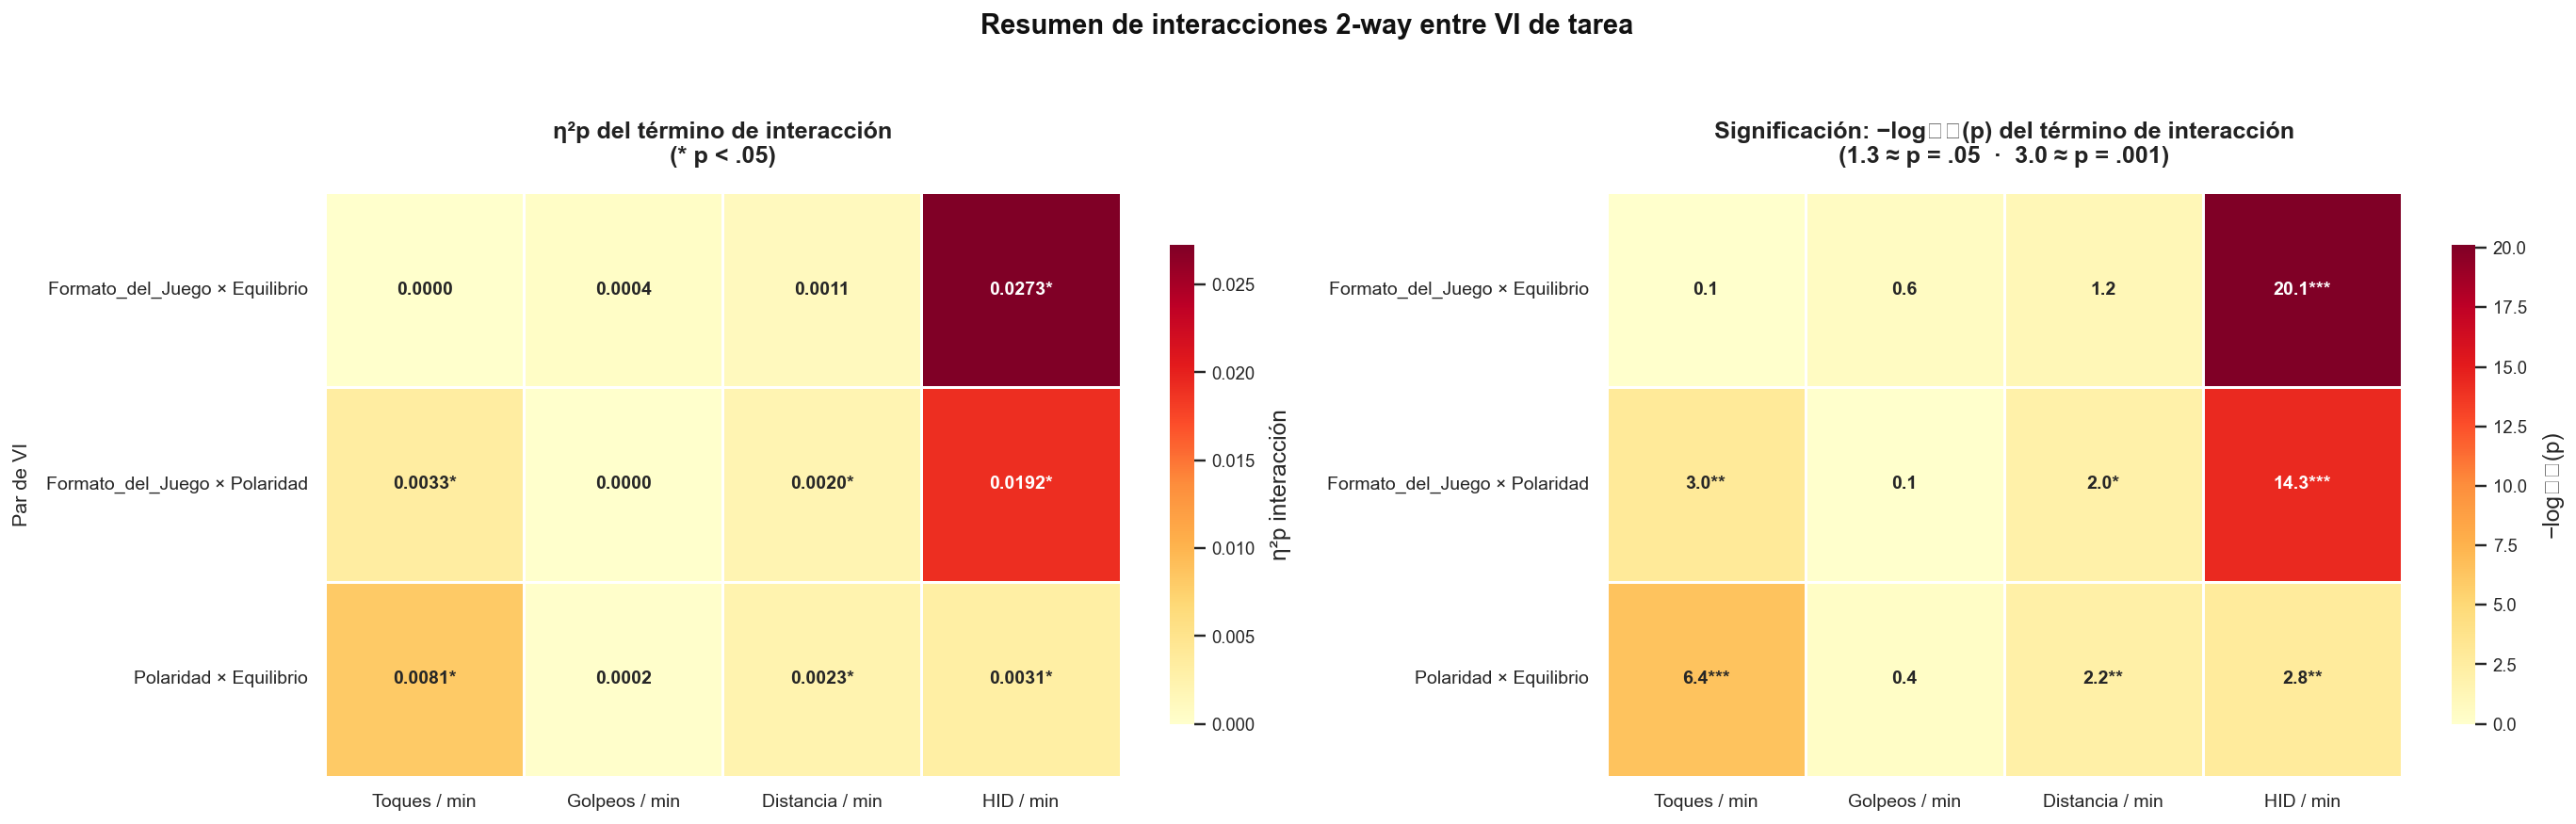

In [5]:
# ── Sección 4: Heatmaps resumen ──────────────────────────

# ── 4.1 Preparar pivots ──────────────────────────────────
pivot_eta = df_anova.pivot_table(
    index="Par VI", columns="VD", values="η²p interacción", aggfunc="first"
)[vd_labels]

pivot_p = df_anova.pivot_table(
    index="Par VI", columns="VD", values="p interacción", aggfunc="first"
)[vd_labels]

pivot_logp = -np.log10(pivot_p.clip(lower=1e-300))

# ── 4.2 Anotaciones con asteriscos ───────────────────────
annot_eta = pd.DataFrame("", index=pivot_eta.index, columns=pivot_eta.columns)
for par in pivot_eta.index:
    for vd_l in pivot_eta.columns:
        eta_val = pivot_eta.loc[par, vd_l]
        p_val = pivot_p.loc[par, vd_l]
        star = "*" if p_val < 0.05 else ""
        annot_eta.loc[par, vd_l] = f"{eta_val:.4f}{star}"

annot_logp = pd.DataFrame("", index=pivot_logp.index, columns=pivot_logp.columns)
for par in pivot_logp.index:
    for vd_l in pivot_logp.columns:
        logp_val = pivot_logp.loc[par, vd_l]
        p_val = pivot_p.loc[par, vd_l]
        star = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else ""))
        annot_logp.loc[par, vd_l] = f"{logp_val:.1f}{star}"

# ── 4.3 Dibujar heatmaps lado a lado ─────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Heatmap 1: η²p
sns.heatmap(
    pivot_eta.astype(float), annot=annot_eta, fmt="", cmap="YlOrRd",
    linewidths=1.5, linecolor="white", ax=ax1, vmin=0,
    cbar_kws={"label": "η²p interacción", "shrink": 0.82},
    annot_kws={"fontsize": 10, "fontweight": "bold"},
)
ax1.set_title(
    "η²p del término de interacción\n(* p < .05)",
    fontsize=13, fontweight="bold", color="#222", pad=16,
)
ax1.set_ylabel("Par de VI", fontsize=11)
ax1.set_xlabel("")
ax1.tick_params(labelsize=10)
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# Heatmap 2: -log10(p)
sns.heatmap(
    pivot_logp.astype(float), annot=annot_logp, fmt="", cmap="YlOrRd",
    linewidths=1.5, linecolor="white", ax=ax2, vmin=0,
    cbar_kws={"label": "−log₁₀(p)", "shrink": 0.82},
    annot_kws={"fontsize": 10, "fontweight": "bold"},
)
ax2.set_title(
    "Significación: −log₁₀(p) del término de interacción\n"
    "(1.3 ≈ p = .05  ·  3.0 ≈ p = .001)",
    fontsize=13, fontweight="bold", color="#222", pad=16,
)
ax2.set_ylabel("")
ax2.set_xlabel("")
ax2.tick_params(labelsize=10)
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)

# Líneas de referencia en heatmap de -log10(p)
# (Las líneas horizontales de referencia se señalan en el título)

fig.suptitle(
    "Resumen de interacciones 2-way entre VI de tarea",
    fontsize=15, fontweight="bold", color="#111", y=1.04,
)
fig.tight_layout()
plt.show()

---
## Sección 5 — Interacciones sobre la inflación de ceros (Golpeos y HID)

Para las **2 VD con inflación de ceros** (Golpeos/min y HID/min), por cada par de VI:

1. **Tabla 2×2 del % de ceros** en cada celda del cruce.
2. **Regresión logística** con `statsmodels` (`GLM` con familia Binomial): `cero ~ C(VI₁) * C(VI₂)`, para evaluar si el término de interacción es significativo sobre la probabilidad de registrar 0.
3. **Interaction plot** del % de ceros (mismo formato que la Sección 2, pero con eje Y = proporción de ceros).

Esto extiende el análisis **interruptor/modulador** al contexto de interacciones: ¿la probabilidad de registrar 0 golpeos o 0 HID depende de la **combinación** de dos VI, no solo de cada una por separado?

In [6]:
# ── 5.1  Tablas 2×2 de % de ceros ────────────────────────

for vd, label in zip(vd_zeros, vd_zeros_labels):
    display(Markdown(f"### VD: **{label}** — % de ceros por celda 2×2"))
    
    for vi1, vi2 in pares_vi:
        filas = []
        for niv1 in vi_niveles[vi1]:
            for niv2 in vi_niveles[vi2]:
                sub = df[(df[vi1] == niv1) & (df[vi2] == niv2)][vd].dropna()
                n_total = len(sub)
                n_ceros = int((sub == 0).sum())
                pct_ceros = round((sub == 0).mean() * 100, 1) if n_total > 0 else np.nan
                filas.append({
                    vi1: niv1,
                    vi2: niv2,
                    "N": n_total,
                    "N ceros": n_ceros,
                    "% ceros": pct_ceros,
                })
        tabla = pd.DataFrame(filas)
        # Pivot para presentar como tabla 2×2
        pivot = tabla.pivot_table(
            index=vi1, columns=vi2, values="% ceros", aggfunc="first"
        )
        display(Markdown(f"**{vi1} × {vi2}**"))
        display(pivot.style.format("{:.1f} %").set_caption(f"% de ceros — {label}"))
    print()

### VD: **Golpeos / min** — % de ceros por celda 2×2

**Formato_del_Juego × Polaridad**

Polaridad,No_polarizado,Polarizado
Formato_del_Juego,,
LSG,42.6 %,18.3 %
SSG,46.4 %,29.3 %


**Formato_del_Juego × Equilibrio**

Equilibrio,Desequilibrio,Equilibrio
Formato_del_Juego,,
LSG,35.6 %,18.8 %
SSG,39.9 %,31.5 %


...

Polaridad,No_polarizado,Polarizado
Formato_del_Juego,,
LSG,36.0 %,16.5 %
SSG,47.4 %,37.8 %


**Formato_del_Juego × Equilibrio**

Equilibrio,Desequilibrio,Equilibrio
Formato_del_Juego,,
LSG,36.3 %,16.3 %
SSG,44.9 %,38.1 %


**Polaridad × Equilibrio**

Equilibrio,Desequilibrio,Equilibrio
Polaridad,,
No_polarizado,48.1 %,36.7 %
Polarizado,36.5 %,23.5 %


In [7]:
# ── 5.2  Regresión logística: interacción sobre la probabilidad de cero ──

filas_logit = []

for vd, label in zip(vd_zeros, vd_zeros_labels):
    # Variable binaria: 1 si es cero, 0 si > 0
    df["_es_cero"] = (df[vd] == 0).astype(int)
    
    for vi1, vi2 in pares_vi:
        formula = f'_es_cero ~ C({vi1}) * C({vi2})'
        try:
            modelo_logit = smf.glm(
                formula, data=df,
                family=sm.families.Binomial()
            ).fit()
            
            # Buscar el p-valor del término de interacción
            inter_params = [p for p in modelo_logit.params.index if ":" in p]
            if inter_params:
                inter_name = inter_params[0]
                p_inter = modelo_logit.pvalues[inter_name]
                coef_inter = modelo_logit.params[inter_name]
                or_inter = np.exp(coef_inter)
            else:
                p_inter = np.nan
                coef_inter = np.nan
                or_inter = np.nan
            
            sig = "***" if p_inter < 0.001 else ("**" if p_inter < 0.01 else ("*" if p_inter < 0.05 else "ns"))
            
            filas_logit.append({
                "VD": label,
                "Par VI": f"{vi1} × {vi2}",
                "Coef. interacción (logit)": round(coef_inter, 4),
                "OR interacción": round(or_inter, 4),
                "p interacción": p_inter,
                "Sig.": sig,
            })
        except Exception as e:
            filas_logit.append({
                "VD": label,
                "Par VI": f"{vi1} × {vi2}",
                "Coef. interacción (logit)": np.nan,
                "OR interacción": np.nan,
                "p interacción": np.nan,
                "Sig.": f"Error: {e}",
            })

# Eliminar columna auxiliar
df.drop(columns=["_es_cero"], inplace=True, errors="ignore")

df_logit = pd.DataFrame(filas_logit)

# Display con formato
df_logit_display = df_logit.copy()
df_logit_display["p interacción"] = df_logit_display["p interacción"].apply(
    lambda p: fmt_p(p) if not np.isnan(p) else "—"
)

display(Markdown("### Regresión logística: interacción sobre la probabilidad de cero"))
display(
    df_logit_display.style
    .set_caption("GLM Binomial — término de interacción sobre P(VD = 0)")
    .map(_color_sig, subset=["Sig."])
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
    ])
)

print("\nOR > 1 → la combinación de niveles aumenta la odds de registrar 0.")
print("OR < 1 → la combinación de niveles reduce la odds de registrar 0.")

### Regresión logística: interacción sobre la probabilidad de cero

,VD,Par VI,Coef. interacción (logit),OR interacción,p interacción,Sig.
0,Golpeos / min,Formato_del_Juego × Polaridad,0.464500,1.591200,0.0322,*
1,Golpeos / min,Formato_del_Juego × Equilibrio,0.499900,1.648500,0.0196,*
2,Golpeos / min,Polaridad × Equilibrio,-0.428100,0.651700,0.0522,ns
3,HID / min,Formato_del_Juego × Polaridad,0.658100,1.931100,0.0029,**
4,HID / min,Formato_del_Juego × Equilibrio,0.791300,2.206400,2.07e-04,***
5,HID / min,Polaridad × Equilibrio,-0.161300,0.851100,0.4643,ns



OR > 1 → la combinación de niveles aumenta la odds de registrar 0.
OR < 1 → la combinación de niveles reduce la odds de registrar 0.


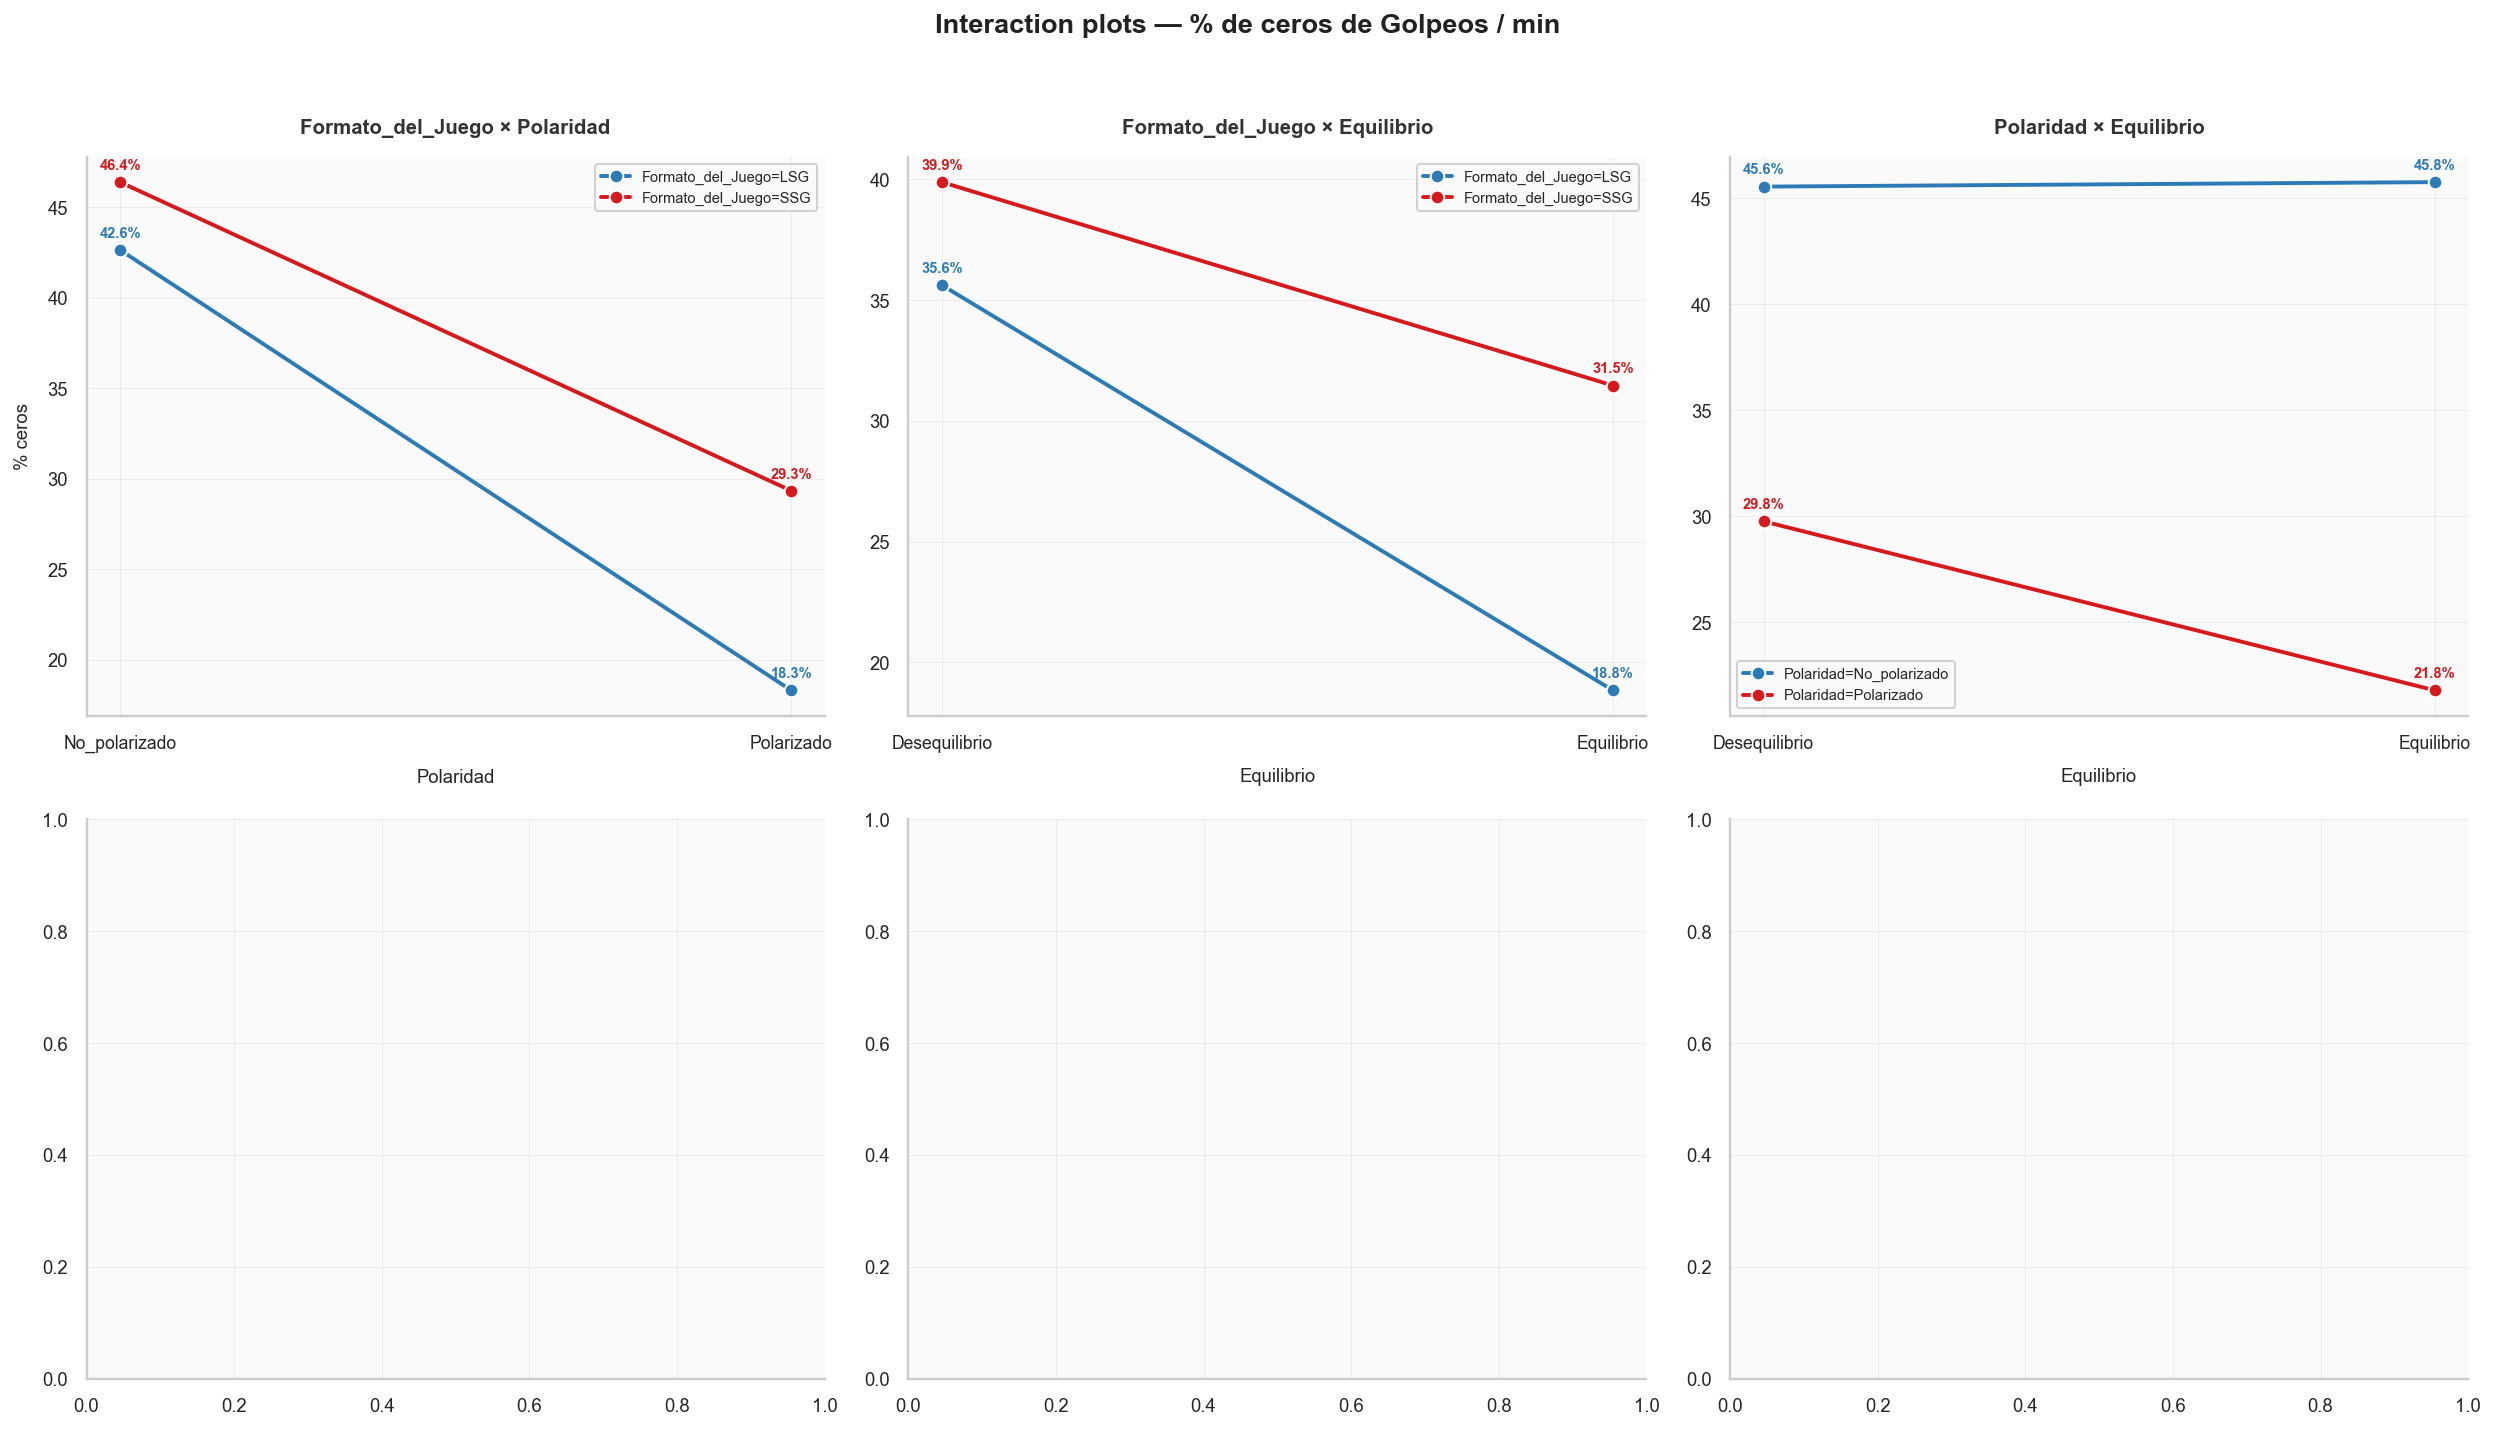

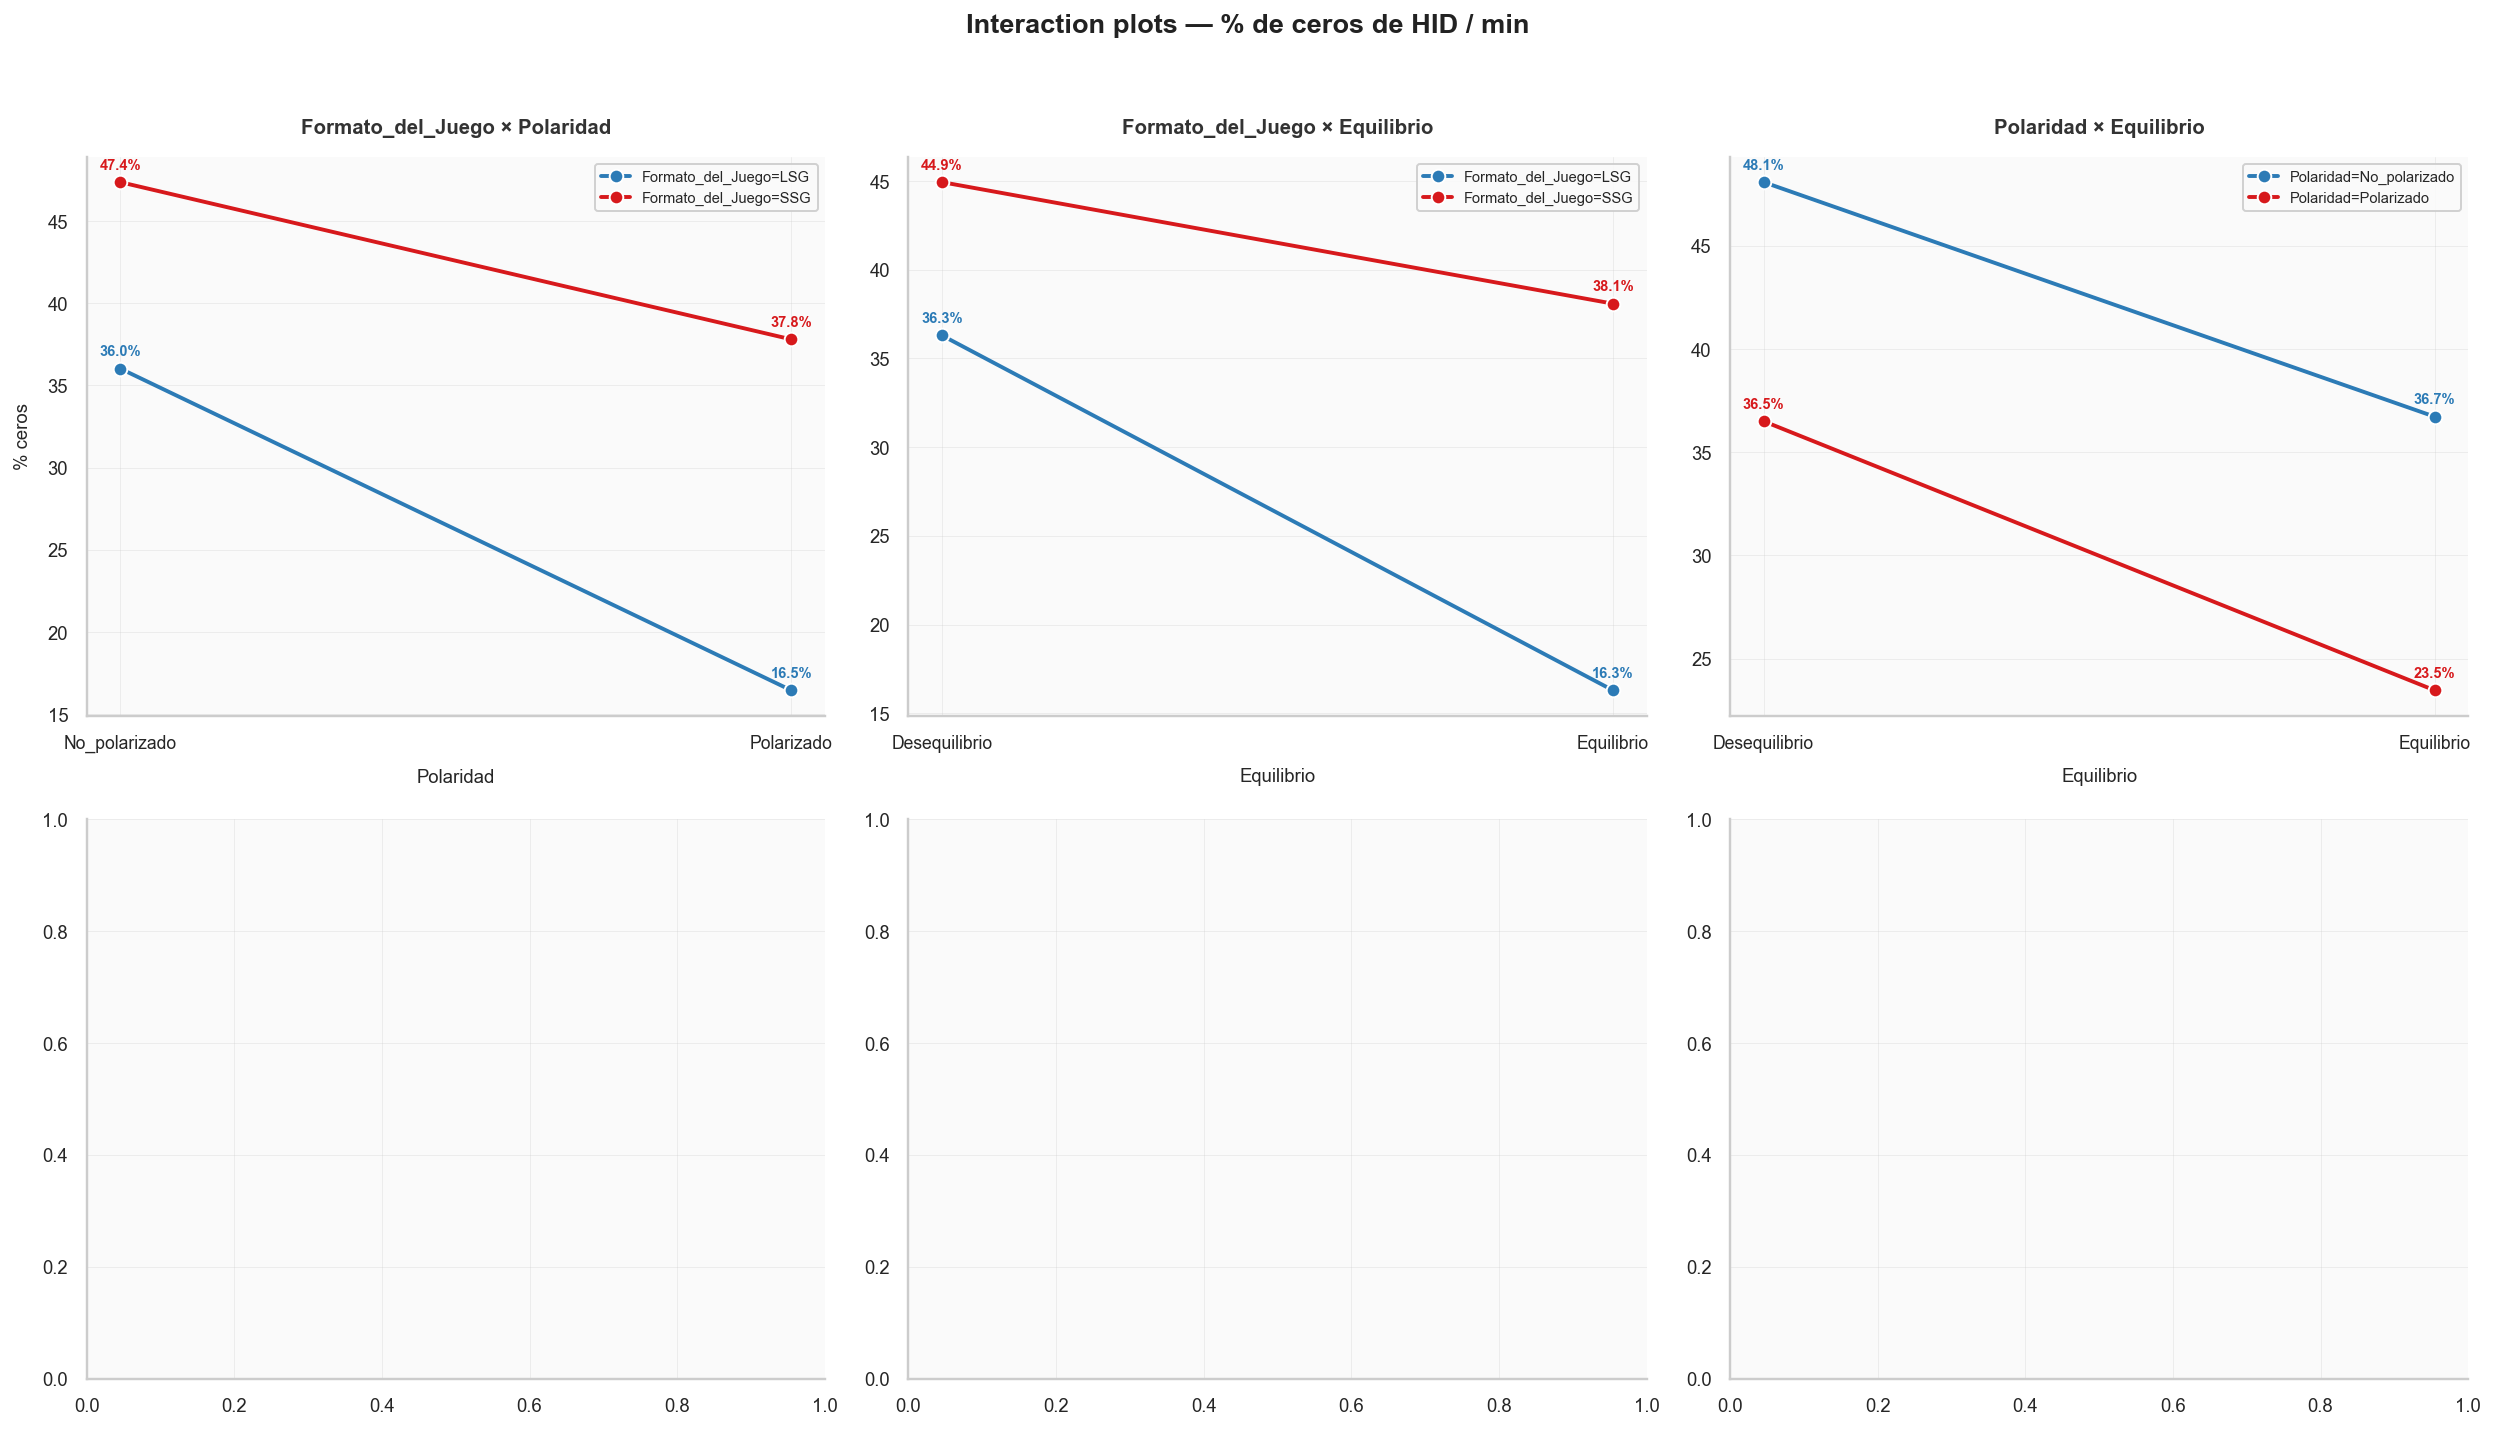

In [8]:
# ── 5.3  Interaction plots del % de ceros ────────────────

for vd, label in zip(vd_zeros, vd_zeros_labels):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()
    
    for idx_par, (vi1, vi2) in enumerate(pares_vi):
        ax = axes[idx_par]
        niveles_vi1 = vi_niveles[vi1]
        niveles_vi2 = vi_niveles[vi2]
        
        for k, niv1 in enumerate(niveles_vi1):
            pcts = []
            for niv2 in niveles_vi2:
                sub = df[(df[vi1] == niv1) & (df[vi2] == niv2)][vd].dropna()
                pct = (sub == 0).mean() * 100 if len(sub) > 0 else 0
                pcts.append(pct)
            
            ax.plot(
                range(len(niveles_vi2)), pcts,
                marker="o", markersize=7, linewidth=2.0,
                color=PAL_INTER[k], label=f"{vi1}={niv1}",
                markeredgecolor="white", markeredgewidth=1.0,
            )
            # Anotar valores
            for x_pos, pct_val in enumerate(pcts):
                ax.annotate(
                    f"{pct_val:.1f}%", xy=(x_pos, pct_val),
                    fontsize=7.5, ha="center", va="bottom",
                    xytext=(0, 5), textcoords="offset points",
                    fontweight="bold", color=PAL_INTER[k],
                )
        
        ax.set_xticks(range(len(niveles_vi2)))
        ax.set_xticklabels(niveles_vi2, fontsize=9)
        ax.set_xlabel(vi2, fontsize=9.5)
        ax.set_ylabel("% ceros" if idx_par % 3 == 0 else "", fontsize=9.5)
        ax.set_title(f"{vi1} × {vi2}", fontsize=10.5, fontweight="bold", color="#333")
        ax.legend(fontsize=7.5, loc="best", framealpha=0.9)
    
    fig.suptitle(
        f"Interaction plots — % de ceros de {label}",
        fontsize=14, fontweight="bold", color="#222", y=1.02,
    )
    fig.tight_layout()
    plt.show()

---
## Sección 6 — Tabla-resumen final y conclusiones

In [9]:
# ── 6.1  Tabla consolidada (24 combinaciones) ordenada por η²p ──

df_resumen_final = df_anova.copy()
df_resumen_final["Significativa"] = df_resumen_final["p interacción"].apply(
    lambda p: "Sí" if p < 0.05 else "No"
)
df_resumen_final["p interacción (fmt)"] = df_resumen_final["p interacción"].apply(fmt_p)
df_resumen_final["η²p interacción (fmt)"] = df_resumen_final["η²p interacción"].apply(
    lambda x: f"{x:.4f}"
)

# Ordenar por η²p descendente
df_resumen_final = df_resumen_final.sort_values("η²p interacción", ascending=False).reset_index(drop=True)

# Seleccionar columnas para display
cols_display = [
    "Par VI", "VD", "ΔΔ", "ΔΔ%", "η²p interacción (fmt)",
    "p interacción (fmt)", "Significativa", "Tamaño",
]

def _color_sig_sn(val):
    if val == "Sí":
        return "background-color: #F8D7DA; font-weight: bold"
    return ""

display(Markdown("### Tabla-resumen final — 24 interacciones ordenadas por η²p"))
display(
    df_resumen_final[cols_display].style
    .set_caption("Resumen de interacciones 2-way (6 pares × 4 VD), ordenadas por η²p descendente")
    .map(_color_tamano, subset=["Tamaño"])
    .map(_color_sig_sn, subset=["Significativa"])
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
    ])
)

### Tabla-resumen final — 24 interacciones ordenadas por η²p

,Par VI,VD,ΔΔ,ΔΔ%,η²p interacción (fmt),p interacción (fmt),Significativa,Tamaño
0,Formato_del_Juego × Equilibrio,HID / min,2.127700,128.750000,0.0273,7.47e-21,Sí,Pequeño
1,Formato_del_Juego × Polaridad,HID / min,1.846100,111.710000,0.0192,4.66e-15,Sí,Pequeño
2,Polaridad × Equilibrio,Toques / min,0.830000,34.090000,0.0081,3.57e-07,Sí,Negligible
3,Formato_del_Juego × Polaridad,Toques / min,0.486300,19.980000,0.0033,0.0011,Sí,Negligible
4,Polaridad × Equilibrio,HID / min,-0.799400,-48.370000,0.0031,0.0016,Sí,Negligible
5,Polaridad × Equilibrio,Distancia / min,-7.827900,-9.730000,0.0023,0.0067,Sí,Negligible
6,Formato_del_Juego × Polaridad,Distancia / min,6.632400,8.240000,0.0020,0.0107,Sí,Negligible
7,Formato_del_Juego × Equilibrio,Distancia / min,4.786000,5.950000,0.0011,0.0567,No,Negligible
8,Formato_del_Juego × Equilibrio,Golpeos / min,-0.020200,-13.340000,0.0004,0.2394,No,Negligible
9,Polaridad × Equilibrio,Golpeos / min,0.014300,9.420000,0.0002,0.4259,No,Negligible


In [10]:
# ── 6.2  Ranking: Top interacciones más relevantes ───────

# Top 5 por η²p
display(Markdown("### Top 5 interacciones por η²p (mayor tamaño de efecto)"))
top_eta = df_resumen_final.head(5)[
    ["Par VI", "VD", "η²p interacción (fmt)", "ΔΔ", "ΔΔ%", "p interacción (fmt)", "Tamaño"]
]
display(top_eta)

# Top 5 por |ΔΔ%|
display(Markdown("### Top 5 interacciones por |ΔΔ%| (mayor impacto relativo)"))
top_dd = (
    df_resumen_final
    .assign(**{"abs_ΔΔ%": df_resumen_final["ΔΔ%"].abs()})
    .sort_values("abs_ΔΔ%", ascending=False)
    .head(5)[
        ["Par VI", "VD", "ΔΔ", "ΔΔ%", "η²p interacción (fmt)", "p interacción (fmt)", "Tamaño"]
    ]
)
display(top_dd)

### Top 5 interacciones por η²p (mayor tamaño de efecto)

,Par VI,VD,η²p interacción (fmt),ΔΔ,ΔΔ%,p interacción (fmt),Tamaño
0,Formato_del_Juego × Equilibrio,HID / min,0.0273,2.1277,128.75,7.47e-21,Pequeño
1,Formato_del_Juego × Polaridad,HID / min,0.0192,1.8461,111.71,4.66e-15,Pequeño
2,Polaridad × Equilibrio,Toques / min,0.0081,0.8300,34.09,3.57e-07,Negligible
3,Formato_del_Juego × Polaridad,Toques / min,0.0033,0.4863,19.98,0.0011,Negligible
4,Polaridad × Equilibrio,HID / min,0.0031,-0.7994,-48.37,0.0016,Negligible


### Top 5 interacciones por |ΔΔ%| (mayor impacto relativo)

,Par VI,VD,ΔΔ,ΔΔ%,η²p interacción (fmt),p interacción (fmt),Tamaño
0,Formato_del_Juego × Equilibrio,HID / min,2.1277,128.75,0.0273,7.47e-21,Pequeño
1,Formato_del_Juego × Polaridad,HID / min,1.8461,111.71,0.0192,4.66e-15,Pequeño
4,Polaridad × Equilibrio,HID / min,-0.7994,-48.37,0.0031,0.0016,Negligible
2,Polaridad × Equilibrio,Toques / min,0.8300,34.09,0.0081,3.57e-07,Negligible
3,Formato_del_Juego × Polaridad,Toques / min,0.4863,19.98,0.0033,0.0011,Negligible


In [11]:
# ── 6.3  Resumen del análisis sobre ceros ────────────────

display(Markdown("### Resumen de interacciones sobre la inflación de ceros (Golpeos y HID)"))

# Combinar info de regresión logística con ANOVA
filas_resumen_ceros = []
for _, row in df_logit.iterrows():
    vd_label = row["VD"]
    par_vi = row["Par VI"]
    
    # Buscar η²p correspondiente del ANOVA sobre la VD continua
    match = df_anova[
        (df_anova["VD"] == vd_label) & (df_anova["Par VI"] == par_vi)
    ]
    eta2p_continua = match["η²p interacción"].values[0] if len(match) > 0 else np.nan
    p_continua = match["p interacción"].values[0] if len(match) > 0 else np.nan
    
    filas_resumen_ceros.append({
        "VD": vd_label,
        "Par VI": par_vi,
        "p interacción (ceros)": fmt_p(row["p interacción"]) if not np.isnan(row["p interacción"]) else "—",
        "OR interacción": round(row["OR interacción"], 3) if not np.isnan(row["OR interacción"]) else "—",
        "Sig. ceros": "Sí" if row["p interacción"] < 0.05 else "No",
        "p interacción (continua)": fmt_p(p_continua),
        "η²p (continua)": f"{eta2p_continua:.4f}",
        "Sig. continua": "Sí" if p_continua < 0.05 else "No",
        "Opera sobre": (
            "Ambas" if (row["p interacción"] < 0.05 and p_continua < 0.05) else
            "Ceros" if row["p interacción"] < 0.05 else
            "Continua" if p_continua < 0.05 else
            "Ninguna"
        ),
    })

df_resumen_ceros = pd.DataFrame(filas_resumen_ceros)

def _color_opera(val):
    mapa = {"Ambas": "#F8D7DA", "Ceros": "#FFF3CD", "Continua": "#D1ECF1", "Ninguna": "#D4EDDA"}
    return f"background-color: {mapa.get(val, '')}"

display(
    df_resumen_ceros.style
    .set_caption("Interacciones sobre la parte de ceros vs. la parte continua")
    .map(_color_opera, subset=["Opera sobre"])
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
    ])
)

### Resumen de interacciones sobre la inflación de ceros (Golpeos y HID)

,VD,Par VI,p interacción (ceros),OR interacción,Sig. ceros,p interacción (continua),η²p (continua),Sig. continua,Opera sobre
0,Golpeos / min,Formato_del_Juego × Polaridad,0.0322,1.591000,Sí,0.8894,0.0000,No,Ceros
1,Golpeos / min,Formato_del_Juego × Equilibrio,0.0196,1.649000,Sí,0.2394,0.0004,No,Ceros
2,Golpeos / min,Polaridad × Equilibrio,0.0522,0.652000,No,0.4259,0.0002,No,Ninguna
3,HID / min,Formato_del_Juego × Polaridad,0.0029,1.931000,Sí,4.66e-15,0.0192,Sí,Ambas
4,HID / min,Formato_del_Juego × Equilibrio,2.07e-04,2.206000,Sí,7.47e-21,0.0273,Sí,Ambas
5,HID / min,Polaridad × Equilibrio,0.4643,0.851000,No,0.0016,0.0031,Sí,Continua


---
## Conclusiones

### 1. ¿Qué interacciones alcanzan significación estadística y tamaño de efecto al menos pequeño?

De las 12 combinaciones analizadas (3 pares × 4 VD), dos interacciones destacan con η²p ≥ .01:

| Par VI | VD | η²p | p | Tamaño |
|:-------|:---|:---:|:---:|:------:|
| **Formato_del_Juego × Equilibrio** | HID / min | 0.027 | 7.5 × 10⁻²¹ | Pequeño |
| **Formato_del_Juego × Polaridad** | HID / min | 0.019 | 4.7 × 10⁻¹⁵ | Pequeño |

El **HID / min** concentra las dos únicas interacciones con efecto no negligible. El Formato_del_Juego es la VI protagonista en ambos casos, confirmando su papel central en el diseño.

### 2. ¿Los efectos base son mayoritariamente aditivos?

- Los interaction plots muestran líneas **aproximadamente paralelas** para Toques/min y Distancia/min → los efectos de las VI son mayoritariamente aditivos en estas VD.
- Para **HID/min**, se observa una **divergencia clara** en los pares Formato_del_Juego × Equilibrio (ΔΔ% = 129 %) y Formato_del_Juego × Polaridad (ΔΔ% = 112 %). El efecto del Equilibrio y la Polaridad sobre HID es mucho mayor en LSG que en SSG.
- **Golpeos/min** no muestra interacciones relevantes (todos los η²p < 0.001).

### 3. ¿Qué interacciones incluir en los GLMM?

**Incluir obligatoriamente:**
- `Formato_del_Juego × Equilibrio` para HID (η²p = 0.027, p < 10⁻²⁰)
- `Formato_del_Juego × Polaridad` para HID (η²p = 0.019, p < 10⁻¹⁴)

**Evaluar caso a caso:**
- `Polaridad × Equilibrio` para Toques (η²p = 0.008, p < 10⁻⁶) y para HID (η²p = 0.003, p = 0.002)

**No incluir:**
- Todas las interacciones con η²p < 0.001 y/o p > .05 (la mayoría de combinaciones para Golpeos y Distancia)

### 4. Interacciones sobre la inflación de ceros (Golpeos y HID)

La regresión logística confirma que las interacciones del Formato_del_Juego operan **significativamente** sobre la probabilidad de registrar un cero:

| VD | Par VI | OR interacción | p |
|:---|:-------|:--------------:|:---:|
| HID / min | Formato_del_Juego × Equilibrio | 2.21 | 2 × 10⁻⁴ |
| HID / min | Formato_del_Juego × Polaridad | 1.93 | 0.003 |
| Golpeos / min | Formato_del_Juego × Equilibrio | 1.65 | 0.020 |
| Golpeos / min | Formato_del_Juego × Polaridad | 1.59 | 0.032 |

→ En los modelos hurdle/zero-inflated, las interacciones del Formato_del_Juego deben incluirse **tanto en el componente logístico** (probabilidad de cero) **como en el componente continuo** (magnitud condicionada).

> **Nota:** Estos resultados descriptivos no controlan por GrupoEdad ni por la estructura jerárquica (observaciones anidadas en jugadores). Los GLMM proporcionarán estimaciones ajustadas.